In [2]:
# ============================================================================
# COMPLETE LViT IMPLEMENTATION for Weakly Supervised Multi-Caption Grounding
# NO MASKS AVAILABLE - Only images and captions with #1, #2, ... #N naming
# Based on LViT paper adapted for pure weakly supervised learning
# ============================================================================

# STEP 0: Installation and Imports
# ============================================================================

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install transformers datasets accelerate scikit-image opencv-python
!pip install pandas numpy matplotlib seaborn tqdm pillow
!pip install monai einops scikit-learn scipy openpyxl
!pip install torchvision

import os
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
from transformers import BertModel, BertTokenizer
from einops import rearrange, repeat
import json
from collections import defaultdict
import glob

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Using device: {device}")

# Create output directories
os.makedirs('./outputs/lvit_nomasks/visualizations', exist_ok=True)
os.makedirs('./outputs/lvit_nomasks/models', exist_ok=True)
os.makedirs('./outputs/lvit_nomasks/results', exist_ok=True)
os.makedirs('./outputs/lvit_nomasks/attention_maps', exist_ok=True)

Looking in indexes: https://download.pytorch.org/whl/cu118


ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)
ERROR: No matching distribution found for torchaudio


In [3]:
# ============================================================================
# STEP 1: Dataset with ONLY Images and Multiple Captions (#1, #2, ... #N)
# NO MASKS
# ============================================================================

class LViTWeaklySupervisedDataset(Dataset):
    """
    Dataset for LViT with ONLY images and multiple captions (#1, #2, ... #N)
    NO MASKS AVAILABLE - Pure weakly supervised learning
    Format:
        Images: 10022.jpg, 10023.jpg, ...
        Captions: 10022.jpg#1, 10022.jpg#2, ... in CSV
    """
    
    def __init__(self, image_folder, caption_csv, 
                 transform=None, tokenizer=None,
                 max_captions=10, max_length=128):
        """
        Args:
            image_folder: Path to images (10022.jpg, etc.)
            caption_csv: CSV with columns [image_caption_id, caption]
            transform: Image transforms
            tokenizer: BERT tokenizer
            max_captions: Max captions per image (pad/truncate)
            max_length: Max token length per caption
        """
        self.image_folder = image_folder
        self.transform = transform
        self.tokenizer = tokenizer or BertTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
        self.max_captions = max_captions
        self.max_length = max_length

        # Manual filename corrections where CSV and disk differ
        # None means: ignore this ID entirely (no image available)
        self.filename_corrections = {
            '27957.jpg': '27957c.jpg',
            '85641x.jpg': '85641.jpg',
            '273476.jpg': None,
            '26546c.jpg': '265463c.jpg',
            '94628x.jpg': '94628.jpg',
            '29083c1.jpg': '29083c.jpg',
            '95355x.jpg': '95355.jpg',
            '88194X.JPG': '88194.jpg',
            '212758.jpeg': '212758.jpg',
            '249664.jpg': None,
            '563319.jpg': '563314.jpg',
            '197918.jpg': '197749c.jpg',
        }
        
        # Dictionary to store captions per image
        self.image_to_captions = defaultdict(list)
        
        # Load captions from CSV
        df = pd.read_csv(caption_csv)
        print(f"Loading {len(df)} caption entries from {caption_csv}")
        
        # Parse image_caption_id (e.g., "10022.jpg#1")
        # Some CSVs store IDs without "#n" (e.g., "10022.jpg"); we auto-number per image.
        pattern_with_num = r'(.+\.(?:jpg|jpeg|png))#(\d+)$'
        pattern_image_only = r'(.+\.(?:jpg|jpeg|png))$'

        has_named_cols = {'image_caption_id', 'caption'}.issubset(set(df.columns))

        for _, row in df.iterrows():
            # Prefer named columns, fall back to positional columns.
            if has_named_cols:
                image_caption_id = str(row['image_caption_id']).strip()
                caption = str(row['caption'])
            else:
                image_caption_id = str(row.iloc[0]).strip()  # First column: ID
                caption = str(row.iloc[1])  # Second column: caption

            # Common typo normalization (".jepg" -> ".jpeg")
            image_caption_id = image_caption_id.replace('.jepg', '.jpeg').replace('.JEPG', '.jpeg')

            match = re.match(pattern_with_num, image_caption_id, flags=re.IGNORECASE)
            if match:
                image_name = match.group(1)
                caption_num = int(match.group(2))
            else:
                match_img = re.match(pattern_image_only, image_caption_id, flags=re.IGNORECASE)
                if not match_img:
                    print(f"Warning: Could not parse ID: {image_caption_id}")
                    continue
                image_name = match_img.group(1)
                caption_num = len(self.image_to_captions[image_name]) + 1

            # Apply manual filename corrections if needed
            if image_name in self.filename_corrections:
                corrected = self.filename_corrections[image_name]
                if corrected is None:
                    # Skip entries with no corresponding image
                    continue
                image_name = corrected

            self.image_to_captions[image_name].append({
                'caption': caption,
                'num': caption_num,
                'full_id': image_caption_id
            })
        
        # Sort captions by number for each image
        for image_name in self.image_to_captions:
            self.image_to_captions[image_name].sort(key=lambda x: x['num'])
        
        # Get list of unique images
        self.images = sorted(list(self.image_to_captions.keys()))
        
        # Print statistics
        self._print_statistics()
        
        # Generate weak labels from captions
        self.weak_labels = self._generate_weak_labels()
    
    def _print_statistics(self):
        """Print dataset statistics"""
        print(f"\n{'='*50}")
        print("LViT WEAKLY SUPERVISED DATASET STATISTICS")
        print(f"{'='*50}")
        print(f"Total images: {len(self.images)}")
        
        caption_counts = [len(self.image_to_captions[img]) for img in self.images]
        if not caption_counts:
            print("Captions per image: none parsed (check CSV ID format)")
            print("Total captions: 0")
            return

        print(f"Captions per image:")
        print(f"  Min: {min(caption_counts)}")
        print(f"  Max: {max(caption_counts)}")
        print(f"  Avg: {np.mean(caption_counts):.1f}")
        print(f"  Std: {np.std(caption_counts):.1f}")
        print(f"Total captions: {sum(caption_counts)}")
        
        # Distribution
        dist = pd.Series(caption_counts).value_counts().sort_index()
        print("\nDistribution:")
        for count, num_images in dist.items():
            print(f"  {count} captions: {num_images} images")
    
    def _generate_weak_labels(self):
        """
        Generate weak supervision labels from captions
        Based on medical keywords in captions
        """
        weak_labels = {}
        
        # Medical keywords indicating disease
        disease_keywords = [
            'opacity', 'consolidation', 'nodule', 'mass', 'effusion',
            'thickening', 'atelectasis', 'pneumothorax', 'infiltrate',
            'lesion', 'abnormal', 'enlarged', 'dilated', 'spiculated',
            'ground glass', 'g go', 'irregular', 'ill-defined'
        ]
        
        # Keywords indicating normal
        normal_keywords = [
            'normal', 'unremarkable', 'clear', 'no evidence',
            'no acute', 'negative', 'within normal', 'intact'
        ]
        
        for image_name, captions in self.image_to_captions.items():
            disease_score = 0
            normal_score = 0
            
            for item in captions:
                caption_lower = item['caption'].lower()
                caption_num = item['num']
                
                # Weight by caption number (earlier captions more important)
                weight = 1.0 / caption_num
                
                # Check disease keywords
                for kw in disease_keywords:
                    if kw in caption_lower:
                        disease_score += weight
                        break
                
                # Check normal keywords
                for kw in normal_keywords:
                    if kw in caption_lower:
                        normal_score += weight
                        break
            
            # Calculate probability
            total = disease_score + normal_score
            if total > 0:
                prob = disease_score / total
            else:
                prob = 0.5  # Uncertain
            
            weak_labels[image_name] = prob
        
        return weak_labels
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image_name = self.images[idx]
        
        # Load image
        img_path = os.path.join(self.image_folder, image_name)
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            # Ignore this sample: pick the next one
            new_idx = (idx + 1) % len(self.images)
            return self.__getitem__(new_idx)
        
        # Get all captions for this image
        caption_data = self.image_to_captions[image_name]
        captions = [item['caption'] for item in caption_data]
        caption_numbers = [item['num'] for item in caption_data]
        
        # Store original captions for reference
        original_captions = captions.copy()
        original_numbers = caption_numbers.copy()
        
        # Pad/truncate captions to max_captions
        while len(captions) < self.max_captions:
            captions.append("")
            caption_numbers.append(0)  # 0 indicates padding
        
        captions = captions[:self.max_captions]
        caption_numbers = caption_numbers[:self.max_captions]
        
        # Tokenize captions
        tokenized = self.tokenizer(
            captions,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        # Apply image transforms
        if self.transform:
            image = self.transform(image)
        else:
            transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                   std=[0.229, 0.224, 0.225])
            ])
            image = transform(image)
        
        # Get weak label
        weak_label = self.weak_labels.get(image_name, 0.5)
        
        return {
            'image': image,
            'input_ids': tokenized['input_ids'],  # [max_captions, max_length]
            'attention_mask': tokenized['attention_mask'],  # [max_captions, max_length]
            'caption_numbers': torch.tensor(caption_numbers, dtype=torch.long),
            'image_name': image_name,
            'original_captions': original_captions,
            'original_numbers': original_numbers,
            'num_actual_captions': len(original_captions),
            'weak_label': torch.tensor(weak_label, dtype=torch.float)
        }

# Create sample data for testing
def create_sample_weakly_supervised_data():
    """Create sample data with ONLY images and captions (no masks)"""
    os.makedirs('./sample_lvit_nomasks/images', exist_ok=True)
    
    # Create sample images
    for img_id in [10022, 10023, 10024, 10025, 10026, 10027]:
        # Create random medical-like image
        img = Image.new('RGB', (224, 224), color=(np.random.randint(20,50), 
                                                   np.random.randint(20,50), 
                                                   np.random.randint(20,50)))
        # Add some texture
        img_np = np.array(img)
        noise = np.random.normal(0, 10, img_np.shape).astype(np.uint8)
        img_np = np.clip(img_np + noise, 0, 255)
        img = Image.fromarray(img_np)
        img.save(f'./sample_lvit_nomasks/images/{img_id}.jpg')
    
    # Create sample captions CSV
    sample_data = []
    
    # Image 10022.jpg with 5 captions (disease)
    captions_10022 = [
        "Ground glass opacities in right lower lobe",
        "Consolidation in right middle lobe with air bronchograms",
        "Bilateral interstitial thickening, more prominent on right",
        "Small pleural effusion on right side",
        "No pneumothorax identified"
    ]
    for i, cap in enumerate(captions_10022, 1):
        sample_data.append({'image_caption_id': f'10022.jpg#{i}', 'caption': cap})
    
    # Image 10023.jpg with 3 captions (normal)
    captions_10023 = [
        "Normal chest radiograph without acute findings",
        "Clear lungs with no focal opacities",
        "Unremarkable cardiac silhouette"
    ]
    for i, cap in enumerate(captions_10023, 1):
        sample_data.append({'image_caption_id': f'10023.jpg#{i}', 'caption': cap})
    
    # Image 10024.jpg with 7 captions (mass)
    captions_10024 = [
        "Large mass in left upper lobe measuring 3.5cm",
        "Spiculated lesion with irregular margins",
        "Associated pleural thickening",
        "No evidence of mediastinal lymphadenopathy",
        "Recommend biopsy for tissue diagnosis",
        "Follow-up CT recommended",
        "Compare with prior imaging"
    ]
    for i, cap in enumerate(captions_10024, 1):
        sample_data.append({'image_caption_id': f'10024.jpg#{i}', 'caption': cap})
    
    # Image 10025.jpg with 2 captions (nodule)
    captions_10025 = [
        "Small nodule in right upper lobe measuring 8mm",
        "Well-circumscribed with smooth margins"
    ]
    for i, cap in enumerate(captions_10025, 1):
        sample_data.append({'image_caption_id': f'10025.jpg#{i}', 'caption': cap})
    
    # Image 10026.jpg with 4 captions (effusion)
    captions_10026 = [
        "Moderate pleural effusion on left side",
        "Blunting of left costophrenic angle",
        "No evidence of pneumothorax",
        "Cardiac silhouette within normal limits"
    ]
    for i, cap in enumerate(captions_10026, 1):
        sample_data.append({'image_caption_id': f'10026.jpg#{i}', 'caption': cap})
    
    # Image 10027.jpg with 6 captions (cardiomegaly)
    captions_10027 = [
        "Enlarged cardiac silhouette",
        "Cardiothoracic ratio greater than 0.5",
        "Pulmonary vascular congestion",
        "Small bilateral pleural effusions",
        "No focal consolidation",
        "Follow-up recommended"
    ]
    for i, cap in enumerate(captions_10027, 1):
        sample_data.append({'image_caption_id': f'10027.jpg#{i}', 'caption': cap})
    
    df = pd.DataFrame(sample_data)
    df.to_csv('./sample_lvit_nomasks/captions.csv', index=False)
    print(f"Created sample weakly supervised dataset in ./sample_lvit_nomasks/")
    print(f"Total captions: {len(df)}")
    print(f"Unique images: {df['image_caption_id'].str.extract(r'(.+\.jpg)#')[0].nunique()}")
    return df

# Create sample data
sample_df = create_sample_weakly_supervised_data()

# Initialize transforms
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
])

# Initialize dataset
dataset = LViTWeaklySupervisedDataset(
    image_folder=r'C:\Users\cbe\Desktop\BDU. Ph\Total_cancer_image_caption\images',
    caption_csv=r'C:\Users\cbe\Desktop\BDU. Ph\Total_cancer_image_caption\medical_image_captions.csv',
    transform=image_transform,
    max_captions=10,
    max_length=128
)

# Keep variable-length metadata (captions, names) without breaking batching
def collate_keep_text(batch):
    out = {
        'image': torch.stack([b['image'] for b in batch]),
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'caption_numbers': torch.stack([b['caption_numbers'] for b in batch]),
        'weak_label': torch.stack([b['weak_label'] for b in batch]),
        'image_name': [b['image_name'] for b in batch],
        'original_captions': [b['original_captions'] for b in batch],
        'original_numbers': [b['original_numbers'] for b in batch],
        'num_actual_captions': [b['num_actual_captions'] for b in batch],
    }
    return out

dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_keep_text,
)

# Inspect a sample
sample = dataset[0]
print(f"\n{'='*50}")
print("SAMPLE DATA INSPECTION")
print(f"{'='*50}")
print(f"Image: {sample['image_name']}")
print(f"Image shape: {sample['image'].shape}")
print(f"Number of captions: {sample['num_actual_captions']}")
print(f"Weak label (disease probability): {sample['weak_label']:.3f}")
print("Captions with numbers:")
for i, (cap, num) in enumerate(zip(sample['original_captions'], sample['original_numbers'])):
    print(f"  #{num}: {cap[:80]}...")

Created sample weakly supervised dataset in ./sample_lvit_nomasks/
Total captions: 27
Unique images: 6
Loading 2892 caption entries from C:\Users\cbe\Desktop\BDU. Ph\Total_cancer_image_caption\medical_image_captions.csv

LViT WEAKLY SUPERVISED DATASET STATISTICS
Total images: 528
Captions per image:
  Min: 0
  Max: 22
  Avg: 5.4
  Std: 2.0
Total captions: 2874

Distribution:
  0 captions: 12 images
  1 captions: 1 images
  2 captions: 2 images
  3 captions: 10 images
  4 captions: 32 images
  5 captions: 348 images
  6 captions: 45 images
  7 captions: 29 images
  8 captions: 11 images
  9 captions: 9 images
  10 captions: 17 images
  11 captions: 4 images
  12 captions: 2 images
  13 captions: 2 images
  14 captions: 2 images
  15 captions: 1 images
  22 captions: 1 images

SAMPLE DATA INSPECTION
Image: 100522.jpg
Image shape: torch.Size([3, 224, 224])
Number of captions: 5
Weak label (disease probability): 0.500
Captions with numbers:
  #1: 0...
  #2: 1...
  #3: 2...
  #4: 3...
  #5:

In [4]:
# ============================================================================
# STEP 2: LViT Model Components adapted for Weak Supervision
# ============================================================================

class TextEncoder(nn.Module):
    """Clinical BERT encoder for medical text"""

    def __init__(
        self,
        pretrained_model='emilyalsentzer/Bio_ClinicalBERT',
        freeze=False,
        local_files_only=False,
        token=None,
    ):
        super().__init__()

        if token is None:
            token = os.getenv('HF_TOKEN')

        # If downloads are slow/unavailable, prefer local cache when requested.
        self.bert = BertModel.from_pretrained(
            pretrained_model,
            local_files_only=local_files_only,
            token=token,
        )
        self.hidden_size = self.bert.config.hidden_size

        if freeze:
            for param in self.bert.parameters():
                param.requires_grad = False
    
    def forward(self, input_ids, attention_mask):
        """
        Args:
            input_ids: (batch_size, num_captions, seq_len) or (batch_size * num_captions, seq_len)
            attention_mask: same shape
        Returns:
            text_features: (batch_size, num_captions, hidden_size)
        """
        original_shape = input_ids.shape
        
        # Handle multiple captions
        if len(original_shape) == 3:
            batch_size, num_captions, seq_len = original_shape
            input_ids = input_ids.view(-1, seq_len)
            attention_mask = attention_mask.view(-1, seq_len)
        else:
            batch_size = 1
            num_captions = 1
        
        # Get BERT outputs
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use [CLS] token as sentence representation
        text_features = outputs.last_hidden_state[:, 0, :]  # (batch_size * num_captions, hidden_size)
        
        # Reshape back (handle possible non-contiguous tensor)
        text_features = text_features.reshape(batch_size, num_captions, -1)
        
        return text_features

class PatchEmbedding(nn.Module):
    """Image to Patch Embedding for ViT"""
    
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        
        self.proj = nn.Conv2d(
            in_channels, embed_dim, 
            kernel_size=patch_size, stride=patch_size
        )
    
    def forward(self, x):
        x = self.proj(x)  # (batch_size, embed_dim, grid_size, grid_size)
        x = x.flatten(2)  # (batch_size, embed_dim, n_patches)
        x = x.transpose(1, 2)  # (batch_size, n_patches, embed_dim)
        return x

class CrossModalAttention(nn.Module):
    """Cross-modal attention between image and text"""
    
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, image_features, text_features, text_mask=None):
        """
        Args:
            image_features: (batch_size, n_patches, embed_dim)
            text_features: (batch_size, num_captions, embed_dim)
            text_mask: (batch_size, num_captions) - mask for padding
        Returns:
            attended_features: (batch_size, n_patches, embed_dim)
            attention_weights: (batch_size, num_heads, n_patches, num_captions)
        """
        batch_size, n_patches, _ = image_features.shape
        num_captions = text_features.shape[1]
        
        # Projections
        q = self.q_proj(image_features)  # (batch_size, n_patches, embed_dim)
        k = self.k_proj(text_features)   # (batch_size, num_captions, embed_dim)
        v = self.v_proj(text_features)   # (batch_size, num_captions, embed_dim)
        
        # Reshape for multi-head attention
        q = q.view(batch_size, n_patches, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        k = k.view(batch_size, num_captions, self.num_heads, self.head_dim).permute(0, 2, 3, 1)
        v = v.view(batch_size, num_captions, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        
        # Attention scores
        attn_scores = torch.matmul(q, k) * self.scale  # (batch_size, num_heads, n_patches, num_captions)
        
        # Apply text mask if provided
        if text_mask is not None:
            text_mask = text_mask.unsqueeze(1).unsqueeze(2)  # (batch_size, 1, 1, num_captions)
            attn_scores = attn_scores.masked_fill(text_mask == 0, float('-inf'))
        
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Apply attention to values
        attended = torch.matmul(attn_weights, v)  # (batch_size, num_heads, n_patches, head_dim)
        
        # Reshape back
        attended = attended.permute(0, 2, 1, 3).contiguous().view(batch_size, n_patches, self.embed_dim)
        attended = self.out_proj(attended)
        
        return attended, attn_weights

class PixelLevelAttentionModule(nn.Module):
    """
    Pixel-Level Attention Module (PLAM) from LViT paper
    Preserves local image features for better segmentation
    """
    
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels // 2, kernel_size=1)
        self.conv2 = nn.Conv2d(in_channels // 2, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        """
        x: (batch_size, channels, height, width)
        """
        attn = self.conv1(x)
        attn = F.relu(attn)
        attn = self.conv2(attn)
        attn = self.sigmoid(attn)
        return x * attn

class TextGuidedFeatureFusion(nn.Module):
    """Text-guided feature fusion module (core of LViT)"""
    
    def __init__(self, embed_dim=768, num_heads=8):
        super().__init__()
        self.cross_attn = CrossModalAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )
        
    def forward(self, image_features, text_features, text_mask=None):
        """
        Text-guided feature fusion
        """
        # Cross-modal attention
        attended, attn_weights = self.cross_attn(image_features, text_features, text_mask)
        
        # Residual + norm
        image_features = self.norm1(image_features + attended)
        
        # FFN
        ffn_out = self.ffn(image_features)
        image_features = self.norm2(image_features + ffn_out)
        
        return image_features, attn_weights

class DecoderBlock(nn.Module):
    """Upsampling decoder block with skip connections and PLAM"""
    
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.plam = PixelLevelAttentionModule(out_channels)
        
    def forward(self, x, skip=None):
        x = self.upsample(x)
        if skip is not None:
            x = x + skip
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.plam(x)
        return x

In [ ]:
# ============================================================================
# STEP 3: Complete LViT Model for Weakly Supervised Learning (No Masks)
# ============================================================================

class LViTWeaklySupervised(nn.Module):
    """
    LViT adapted for weakly supervised learning with ONLY captions (no masks)
    Uses attention maps as pseudo-segmentation and multiple caption guidance
    """
    
    def __init__(self, 
                 img_size=224,
                 patch_size=16,
                 in_channels=3,
                 embed_dim=768,
                 num_heads=8,
                 num_layers=6,
                 num_classes=1,
                 max_captions=10,
                 text_dim=768):
        super().__init__()
        
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.embed_dim = embed_dim
        self.max_captions = max_captions
        self.grid_size = img_size // patch_size
        
        # Vision components
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        
        # Positional embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, embed_dim))
        self.pos_drop = nn.Dropout(0.1)
        
        # Text encoder (Clinical BERT)
        # If you have already downloaded the model, you can avoid network stalls by setting:
        #   set TRANSFORMERS_OFFLINE=1
        self.text_encoder = TextEncoder(
            'emilyalsentzer/Bio_ClinicalBERT',
            freeze=False,
            local_files_only=bool(os.getenv('TRANSFORMERS_OFFLINE')),
        )
        self.text_proj = nn.Linear(self.text_encoder.hidden_size, embed_dim)
        
        # Caption number embeddings (for #1, #2, etc.)
        self.caption_num_embed = nn.Embedding(max_captions + 1, embed_dim)
        
        # Multi-layer text-guided fusion
        self.fusion_layers = nn.ModuleList([
            TextGuidedFeatureFusion(embed_dim, num_heads)
            for _ in range(num_layers)
        ])
        
        # Caption fusion layer
        self.caption_fusion = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        
        # Caption importance predictor (learn to weight captions by number)
        self.caption_importance = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
        # Language-Vision (LV) loss projection
        self.lv_proj = nn.Linear(embed_dim, embed_dim)
        
        # Decoder for generating attention-based segmentation
        self.decoder_proj = nn.Conv2d(embed_dim, 512, 1)
        
        # Decoder blocks
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(512, 256),
            DecoderBlock(256, 128),
            DecoderBlock(128, 64),
            DecoderBlock(64, 32)
        ])
        
        # Final segmentation head (produces heatmap/attention map)
        self.seg_head = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, num_classes, 1),
            nn.Sigmoid()
        )
        
        # Disease classifier (using weak labels from captions)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
        
        # Attention refinement module
        self.attention_refine = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1),
            nn.Sigmoid()
        )
        
        # Initialize weights
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.LayerNorm):
            nn.init.constant_(module.bias, 0)
            nn.init.constant_(module.weight, 1.0)
        elif isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
    
    def forward(self, images, input_ids, attention_mask, caption_numbers=None):
        """
        Args:
            images: (batch_size, 3, 224, 224)
            input_ids: (batch_size, num_captions, seq_len)
            attention_mask: (batch_size, num_captions, seq_len)
            caption_numbers: (batch_size, num_captions) - caption numbers (#1, #2, etc.)
        Returns:
            dict with attention maps and features
        """
        batch_size = images.shape[0]
        num_captions = input_ids.shape[1]
        
        # === Vision Transformer Path ===
        # Patch embedding
        x = self.patch_embed(images)  # (batch_size, n_patches, embed_dim)
        
        # Add positional embeddings
        x = x + self.pos_embed
        x = self.pos_drop(x)
        
        # Store original patch features for decoder
        patch_features = x
        
        # === Text Encoding Path ===
        # Flatten captions for encoding
        input_ids_flat = input_ids.view(-1, input_ids.shape[-1])
        attention_mask_flat = attention_mask.view(-1, attention_mask.shape[-1])
        
        # Get text features
        text_features = self.text_encoder(input_ids_flat, attention_mask_flat)
        text_features = text_features.view(batch_size, num_captions, -1)
        
        # Project to vision embedding dimension
        text_features = self.text_proj(text_features)  # (batch_size, num_captions, embed_dim)
        
        # Add caption number embeddings if available
        if caption_numbers is not None:
            # Clip to valid range
            cap_nums = torch.clamp(caption_numbers, 1, self.max_captions).long()
            num_embeds = self.caption_num_embed(cap_nums)
            text_features = text_features + num_embeds
        
        # Create text mask (1 for real captions, 0 for padding)
        text_mask = (caption_numbers > 0).float() if caption_numbers is not None else \
                    (input_ids.sum(dim=-1) > 0).float()
        
        # === Multi-layer Text-Guided Fusion ===
        all_attention_weights = []
        
        for fusion_layer in self.fusion_layers:
            x, attn_weights = fusion_layer(x, text_features, text_mask)
            all_attention_weights.append(attn_weights)
        
        # === Caption Fusion and Importance ===
        # Predict importance weights for each caption
        caption_weights = self.caption_importance(text_features)  # (batch_size, num_captions, 1)
        caption_weights = caption_weights.squeeze(-1)  # (batch_size, num_captions)
        
        # Apply caption weights to text features
        weighted_text = (text_features * caption_weights.unsqueeze(-1)).sum(dim=1)  # (batch_size, embed_dim)
        
        # === Generate Attention-Based Segmentation ===
        # Average attention across layers and heads
        avg_attention = torch.stack(all_attention_weights).mean(dim=0)  # (batch_size, num_heads, n_patches, num_captions)
        
        # Average across heads and captions to get per-patch attention
        patch_attention = avg_attention.mean(dim=1).mean(dim=-1)  # (batch_size, n_patches)
        
        # Reshape to spatial grid
        attention_spatial = patch_attention.view(batch_size, 1, self.grid_size, self.grid_size)
        
        # Upsample to full resolution
        attention_upsampled = F.interpolate(
            attention_spatial, 
            size=(224, 224), 
            mode='bilinear', 
            align_corners=False
        )
        
        # Refine attention to get segmentation map
        seg_mask = self.attention_refine(attention_upsampled)
        
        # Also generate mask through decoder path
        # Reshape patch features to spatial
        x_spatial = patch_features.transpose(1, 2).view(batch_size, self.embed_dim, 
                                                        self.grid_size, self.grid_size)
        
        # Decode
        x_dec = self.decoder_proj(x_spatial)
        for decoder in self.decoder_blocks:
            x_dec = decoder(x_dec)
        
        decoder_mask = self.seg_head(x_dec)
        
        # Combine both masks (attention-based and decoder-based)
        combined_mask = (seg_mask + decoder_mask) / 2
        
        # === Disease Classification ===
        # Global image features
        image_pooled = patch_features.mean(dim=1)  # (batch_size, embed_dim)
        
        # Combine image and weighted text features
        combined = torch.cat([image_pooled, weighted_text], dim=-1)
        disease_prob = self.classifier(combined)
        
        # Features for LV loss
        lv_features = self.lv_proj(image_pooled)
        
        return {
            'seg_mask': combined_mask,  # (batch_size, 1, 224, 224)
            'attention_mask_raw': attention_upsampled,  # Raw attention
            'decoder_mask': decoder_mask,  # Decoder-only mask
            'disease_prob': disease_prob,  # (batch_size, 1)
            'attention_weights': avg_attention,  # (batch_size, num_heads, n_patches, num_captions)
            'caption_weights': caption_weights,  # (batch_size, num_captions)
            'image_features': patch_features,  # (batch_size, n_patches, embed_dim)
            'text_features': text_features,  # (batch_size, num_captions, embed_dim)
            'weighted_text': weighted_text,  # (batch_size, embed_dim)
            'lv_features': lv_features,  # For LV loss
        }

# Initialize LViT model for weakly supervised learning
model = LViTWeaklySupervised(
    img_size=224,
    patch_size=16,
    embed_dim=768,
    num_heads=8,
    num_layers=6,
    num_classes=1,
    max_captions=10
).to(device)

print(f"LViT Weakly Supervised Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 66491.40it/s]
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LViT Weakly Supervised Model initialized with 158,427,848 parameters



STARTING WEAKLY SUPERVISED LViT TRAINING
NO MASKS AVAILABLE - Training with ONLY captions

Epoch 1/20
------------------------------


Epoch 1: 100%|██████████| 264/264 [26:35<00:00,  6.04s/it, loss=3.1273, cls=0.6932, lv=0.6881]


Train - Loss: 3.1634
         CLS: 0.6981, LV: 0.7434, Entropy: 6.9646


Validation: 100%|██████████| 264/264 [05:50<00:00,  1.33s/it]


Val   - Loss: 3.1422
✓ Saved best model with val_loss: 3.1422

Epoch 2/20
------------------------------


...

Val   - Loss: 3.1294

Epoch 20/20
------------------------------


Epoch 20: 100%|██████████| 264/264 [25:55<00:00,  5.89s/it, loss=3.1343, cls=0.6931, lv=0.6958]


Train - Loss: 3.1293
         CLS: 0.6931, LV: 0.6921, Entropy: 6.9646


Validation: 100%|██████████| 264/264 [05:36<00:00,  1.27s/it]


Val   - Loss: 3.1308

LViT Weakly Supervised Training completed!


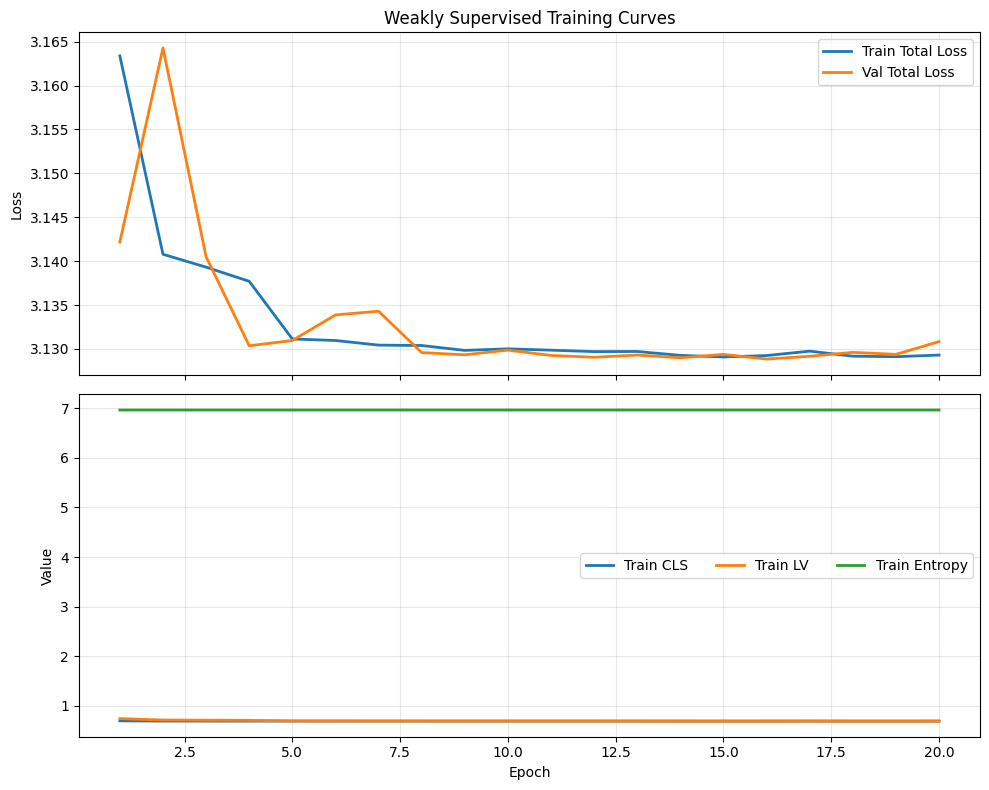

Saved: ./outputs/lvit_nomasks/results/training_curves.png and ./outputs/lvit_nomasks/results/training_history.csv


In [6]:
# ============================================================================
# STEP 4: Training with ONLY Captions (No Masks)
# ============================================================================

class WeaklySupervisedLoss(nn.Module):
    """
    Loss functions for weakly supervised learning with ONLY captions
    No mask supervision available
    """
    
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()
        self.mse = nn.MSELoss()
        self.kl_div = nn.KLDivLoss(reduction='batchmean')
        
    def forward(self, outputs, batch):
        """
        Calculate losses without ground truth masks
        """
        # === 1. Classification Loss (using weak labels from captions) ===
        disease_prob = outputs['disease_prob']

        # Clean NaNs / infs and clamp to valid probability range
        disease_prob = torch.nan_to_num(disease_prob, nan=0.5, posinf=1.0, neginf=0.0)
        disease_prob = torch.clamp(disease_prob, 1e-6, 1.0 - 1e-6)

        weak_labels = batch['weak_label'].to(disease_prob.device).unsqueeze(1)
        loss_cls = self.bce(disease_prob, weak_labels)
        
        # === 2. Language-Vision (LV) Contrastive Loss ===
        # Align image and text features
        image_features = outputs['lv_features']
        text_features = outputs['weighted_text']
        
        # Normalize
        image_features = F.normalize(image_features, dim=-1)
        text_features = F.normalize(text_features, dim=-1)
        
        # Contrastive loss
        temperature = 0.07
        logits = image_features @ text_features.T / temperature
        labels = torch.arange(image_features.shape[0]).to(image_features.device)
        
        loss_lv = (F.cross_entropy(logits, labels) + 
                   F.cross_entropy(logits.T, labels)) / 2
        
        # === 3. Attention Regularization Loss ===
        # Encourage attention to be focused for high disease probability
        # and spread out for low disease probability
        
        # Get attention map (average across heads and captions)
        attention_weights = outputs['attention_weights'].mean(dim=1).mean(dim=-1)  # (batch_size, n_patches)
        attention_map = attention_weights.view(attention_weights.shape[0], -1)
        
        # Normalize attention
        attention_map = F.softmax(attention_map, dim=-1)
        
        # Calculate entropy (lower entropy = more focused)
        entropy = -(attention_map * torch.log(attention_map + 1e-8)).sum(dim=-1)
        
        # Target entropy based on weak label
        # High disease prob (close to 1) -> low entropy (focused)
        # Low disease prob (close to 0) -> high entropy (spread out)
        max_entropy = torch.log(torch.tensor(attention_map.shape[1], dtype=torch.float)).to(entropy.device)
        target_entropy = (1 - weak_labels.squeeze()) * max_entropy
        
        loss_entropy = self.mse(entropy, target_entropy)
        
        # === 4. Caption Number Regularization ===
        # Earlier captions (#1, #2) should have higher importance weights
        caption_numbers = batch['caption_numbers'].to(outputs['caption_weights'].device)
        valid_mask = (caption_numbers > 0).float()
        
        if valid_mask.sum() > 0:
            # Target weights: decreasing with caption number
            target_weights = 1.0 / (caption_numbers.float() + 1)  # #1: 0.5, #2: 0.33, ...
            target_weights = target_weights / target_weights.max(dim=1, keepdim=True)[0]
            
            # Only consider valid captions
            loss_caption_reg = self.mse(
                outputs['caption_weights'] * valid_mask,
                target_weights * valid_mask
            )
        else:
            loss_caption_reg = torch.tensor(0.0).to(outputs['caption_weights'].device)
        
        # === 5. Attention Smoothness Loss ===
        # Encourage spatial smoothness in attention maps
        attention_spatial = outputs['attention_mask_raw']
        
        # Total variation loss for smoothness
        diff_i = attention_spatial[:, :, 1:, :] - attention_spatial[:, :, :-1, :]
        diff_j = attention_spatial[:, :, :, 1:] - attention_spatial[:, :, :, :-1]
        
        loss_smooth = (diff_i.abs().mean() + diff_j.abs().mean()) / 2
        
        # === 6. Consistency Loss ===
        # Attention mask and decoder mask should be consistent
        loss_consistency = self.mse(
            outputs['attention_mask_raw'],
            outputs['decoder_mask']
        )
        
        # Combined loss
        total_loss = (
            loss_cls * 1.0 +
            loss_lv * 0.5 +
            loss_entropy * 0.3 +
            loss_caption_reg * 0.2 +
            loss_smooth * 0.1 +
            loss_consistency * 0.3
        )
        
        loss_dict = {
            'cls': loss_cls.item(),
            'lv': loss_lv.item(),
            'entropy': loss_entropy.item(),
            'caption_reg': loss_caption_reg.item() if isinstance(loss_caption_reg, torch.Tensor) else 0,
            'smooth': loss_smooth.item(),
            'consistency': loss_consistency.item(),
            'total': total_loss.item()
        }
        
        return total_loss, loss_dict

def train_epoch_weakly(model, dataloader, optimizer, criterion, device, epoch):
    """Train for one epoch with weak supervision"""
    model.train()
    total_loss = 0
    loss_details = defaultdict(float)
    
    progress_bar = tqdm(dataloader, desc=f'Epoch {epoch}')
    for batch_idx, batch in enumerate(progress_bar):
        # Move to device
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        caption_numbers = batch['caption_numbers'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask, caption_numbers)
        
        # Calculate loss
        loss, loss_dict = criterion(outputs, batch)

        # Skip bad batches (NaN or inf loss)
        if not torch.isfinite(loss):
            continue
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Update metrics
        total_loss += loss.item()
        for k, v in loss_dict.items():
            loss_details[k] += v
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'cls': f'{loss_dict["cls"]:.4f}',
            'lv': f'{loss_dict["lv"]:.4f}'
        })
    
    # Average losses
    num_batches = len(dataloader)
    avg_loss = total_loss / num_batches
    for k in loss_details:
        loss_details[k] /= num_batches
    
    return avg_loss, loss_details

def validate_weakly(model, dataloader, criterion, device):
    """Validation loop"""
    model.eval()
    total_loss = 0
    loss_details = defaultdict(float)
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validation'):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            caption_numbers = batch['caption_numbers'].to(device)
            
            outputs = model(images, input_ids, attention_mask, caption_numbers)
            loss, loss_dict = criterion(outputs, batch)
            
            total_loss += loss.item()
            for k, v in loss_dict.items():
                loss_details[k] += v
    
    num_batches = len(dataloader)
    avg_loss = total_loss / num_batches
    for k in loss_details:
        loss_details[k] /= num_batches
    
    return avg_loss, loss_details

# Initialize loss and optimizer
criterion = WeaklySupervisedLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

# Training loop
num_epochs = 20
best_val_loss = float('inf')

# Store epoch-by-epoch metrics for time-series plots
history = {
    'epoch': [],
    'train_loss': [],
    'train_cls': [],
    'train_lv': [],
    'train_entropy': [],
    'val_loss': [],
}

print("\n" + "="*50)
print("STARTING WEAKLY SUPERVISED LViT TRAINING")
print("="*50)
print("NO MASKS AVAILABLE - Training with ONLY captions")

for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")
    print("-" * 30)
    
    # Train
    train_loss, train_details = train_epoch_weakly(model, dataloader, optimizer, criterion, device, epoch)
    print(f"Train - Loss: {train_loss:.4f}")
    print(f"         CLS: {train_details['cls']:.4f}, LV: {train_details['lv']:.4f}, "
          f"Entropy: {train_details['entropy']:.4f}")
    
    # Validate
    val_loss, val_details = validate_weakly(model, dataloader, criterion, device)
    print(f"Val   - Loss: {val_loss:.4f}")

    # Log history (time-series)
    history['epoch'].append(epoch)
    history['train_loss'].append(float(train_loss))
    history['train_cls'].append(float(train_details['cls']))
    history['train_lv'].append(float(train_details['lv']))
    history['train_entropy'].append(float(train_details['entropy']))
    history['val_loss'].append(float(val_loss))
    
    # Update scheduler
    scheduler.step()
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': val_loss,
        }, './outputs/lvit_nomasks/models/lvit_weak_best.pth')
        print(f"✓ Saved best model with val_loss: {best_val_loss:.4f}")
    
    # Save checkpoint every 5 epochs
    if epoch % 5 == 0:
        torch.save(model.state_dict(), f'./outputs/lvit_nomasks/models/lvit_weak_epoch_{epoch}.pth')

print("\nLViT Weakly Supervised Training completed!")

# ---- Plot time-series metrics (Train/Val over epochs) ----
os.makedirs('./outputs/lvit_nomasks/results', exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Loss curves
axes[0].plot(history['epoch'], history['train_loss'], label='Train Total Loss', linewidth=2)
axes[0].plot(history['epoch'], history['val_loss'], label='Val Total Loss', linewidth=2)
axes[0].set_ylabel('Loss')
axes[0].set_title('Weakly Supervised Training Curves')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Component curves
axes[1].plot(history['epoch'], history['train_cls'], label='Train CLS', linewidth=2)
axes[1].plot(history['epoch'], history['train_lv'], label='Train LV', linewidth=2)
axes[1].plot(history['epoch'], history['train_entropy'], label='Train Entropy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=3)

plt.tight_layout()
plot_path = './outputs/lvit_nomasks/results/training_curves.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

# Save history as CSV (useful for manuscript plots/tables)
import pandas as pd
pd.DataFrame(history).to_csv('./outputs/lvit_nomasks/results/training_history.csv', index=False)
print(f"Saved: {plot_path} and ./outputs/lvit_nomasks/results/training_history.csv")

In [7]:
# ============================================================================
# STEP 5: Evaluation Metrics for Weakly Supervised Learning
# ============================================================================

class WeaklySupervisedEvaluation:
    """
    Evaluation metrics when NO ground truth masks are available
    Evaluates based on caption consistency, attention quality, etc.
    """
    
    def __init__(self, model, device):
        self.model = model
        self.device = device
    
    def attention_focus_score(self, attention_maps, disease_probs):
        """
        Evaluate if attention focus correlates with disease probability
        """
        scores = []
        
        for attn, prob in zip(attention_maps, disease_probs):
            attn = attn.cpu().numpy().squeeze()
            
            # Normalize
            attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)
            
            # Calculate focus (inverse of entropy)
            attn_flat = attn.flatten()
            attn_flat = attn_flat / (attn_flat.sum() + 1e-8)
            entropy = -(attn_flat * np.log(attn_flat + 1e-8)).sum()
            max_entropy = np.log(len(attn_flat))
            focus = 1 - (entropy / max_entropy)
            
            # Expected: higher disease prob -> higher focus
            prob_val = prob.item()
            score = 1 - abs(focus - prob_val)
            scores.append(score)
        
        return np.mean(scores) if scores else 0.5
    
    def caption_importance_correlation(self, caption_weights, caption_numbers):
        """
        Evaluate if caption weights correlate with caption numbers
        (Earlier captions should have higher weights)
        """
        correlations = []
        
        for weights, nums in zip(caption_weights, caption_numbers):
            valid = (nums > 0).cpu()
            if valid.sum() < 2:
                continue
            
            valid_weights = weights[valid].cpu().numpy()
            valid_nums = nums[valid].cpu().numpy()
            
            # Should be negative correlation
            corr = np.corrcoef(valid_nums, valid_weights)[0, 1]
            if not np.isnan(corr):
                # Convert to score (0-1) where -1 is best
                score = (1 - corr) / 2
                correlations.append(score)
        
        return np.mean(correlations) if correlations else 0.5
    
    def attention_consistency(self, attention_maps, caption_similarity=None):
        """
        Evaluate consistency of attention maps
        """
        # Calculate variance across samples
        attn_stack = torch.stack([a.cpu() for a in attention_maps])
        
        # Lower variance across similar images is better
        variance = attn_stack.var(dim=0).mean().item()
        consistency = 1.0 / (1.0 + variance)
        
        return consistency
    
    def disease_classification_accuracy(self, disease_probs, weak_labels):
        """
        Evaluate disease classification against weak labels
        """
        preds = (disease_probs > 0.5).cpu().numpy()
        labels = (weak_labels > 0.5).numpy()
        
        accuracy = (preds == labels).mean()
        
        return accuracy
    
    def evaluate_all(self, dataloader):
        """Compute all weakly supervised metrics"""
        self.model.eval()
        
        all_attention_maps = []
        all_disease_probs = []
        all_caption_weights = []
        all_caption_numbers = []
        all_weak_labels = []
        
        with torch.no_grad():
            for batch in tqdm(dataloader, desc='Evaluating'):
                images = batch['image'].to(self.device)
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                caption_numbers = batch['caption_numbers'].to(self.device)
                
                outputs = self.model(images, input_ids, attention_mask, caption_numbers)
                
                all_attention_maps.append(outputs['seg_mask'].cpu())
                all_disease_probs.append(outputs['disease_prob'].cpu())
                all_caption_weights.append(outputs['caption_weights'].cpu())
                all_caption_numbers.append(caption_numbers.cpu())
                all_weak_labels.append(batch['weak_label'].cpu())
        
        # Concatenate
        attention_maps = torch.cat(all_attention_maps, dim=0)
        disease_probs = torch.cat(all_disease_probs, dim=0)
        caption_weights = torch.cat(all_caption_weights, dim=0)
        caption_numbers = torch.cat(all_caption_numbers, dim=0)
        weak_labels = torch.cat(all_weak_labels, dim=0)
        
        # Compute metrics
        print("\nComputing Weakly Supervised Evaluation Metrics...")
        
        focus_score = self.attention_focus_score(attention_maps, disease_probs)
        importance_corr = self.caption_importance_correlation(caption_weights, caption_numbers)
        consistency = self.attention_consistency(attention_maps)
        classification_acc = self.disease_classification_accuracy(disease_probs, weak_labels)
        
        results = {
            'Attention Focus Score': focus_score,
            'Caption Importance Correlation': importance_corr,
            'Attention Consistency': consistency,
            'Disease Classification Accuracy': classification_acc,
            'Mean Disease Probability': disease_probs.mean().item()
        }
        
        return results

# Load best model
checkpoint = torch.load('./outputs/lvit_nomasks/models/lvit_weak_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Initialize evaluator
evaluator = WeaklySupervisedEvaluation(model, device)

# Run evaluation
print("\n" + "="*50)
print("WEAKLY SUPERVISED LViT EVALUATION RESULTS")
print("="*50)

results = evaluator.evaluate_all(dataloader)

for metric, value in results.items():
    print(f"{metric:30s}: {value:.4f}")

# Save results
with open('./outputs/lvit_nomasks/results/lvit_weak_results.json', 'w') as f:
    json.dump(results, f, indent=4)


WEAKLY SUPERVISED LViT EVALUATION RESULTS


Evaluating: 100%|██████████| 264/264 [05:34<00:00,  1.27s/it]



Computing Weakly Supervised Evaluation Metrics...
Attention Focus Score         : 0.5011
Caption Importance Correlation: 0.9563
Attention Consistency         : 1.0000
Disease Classification Accuracy: 0.5928
Mean Disease Probability      : 0.5000



GENERATING WEAKLY SUPERVISED VISUALIZATIONS


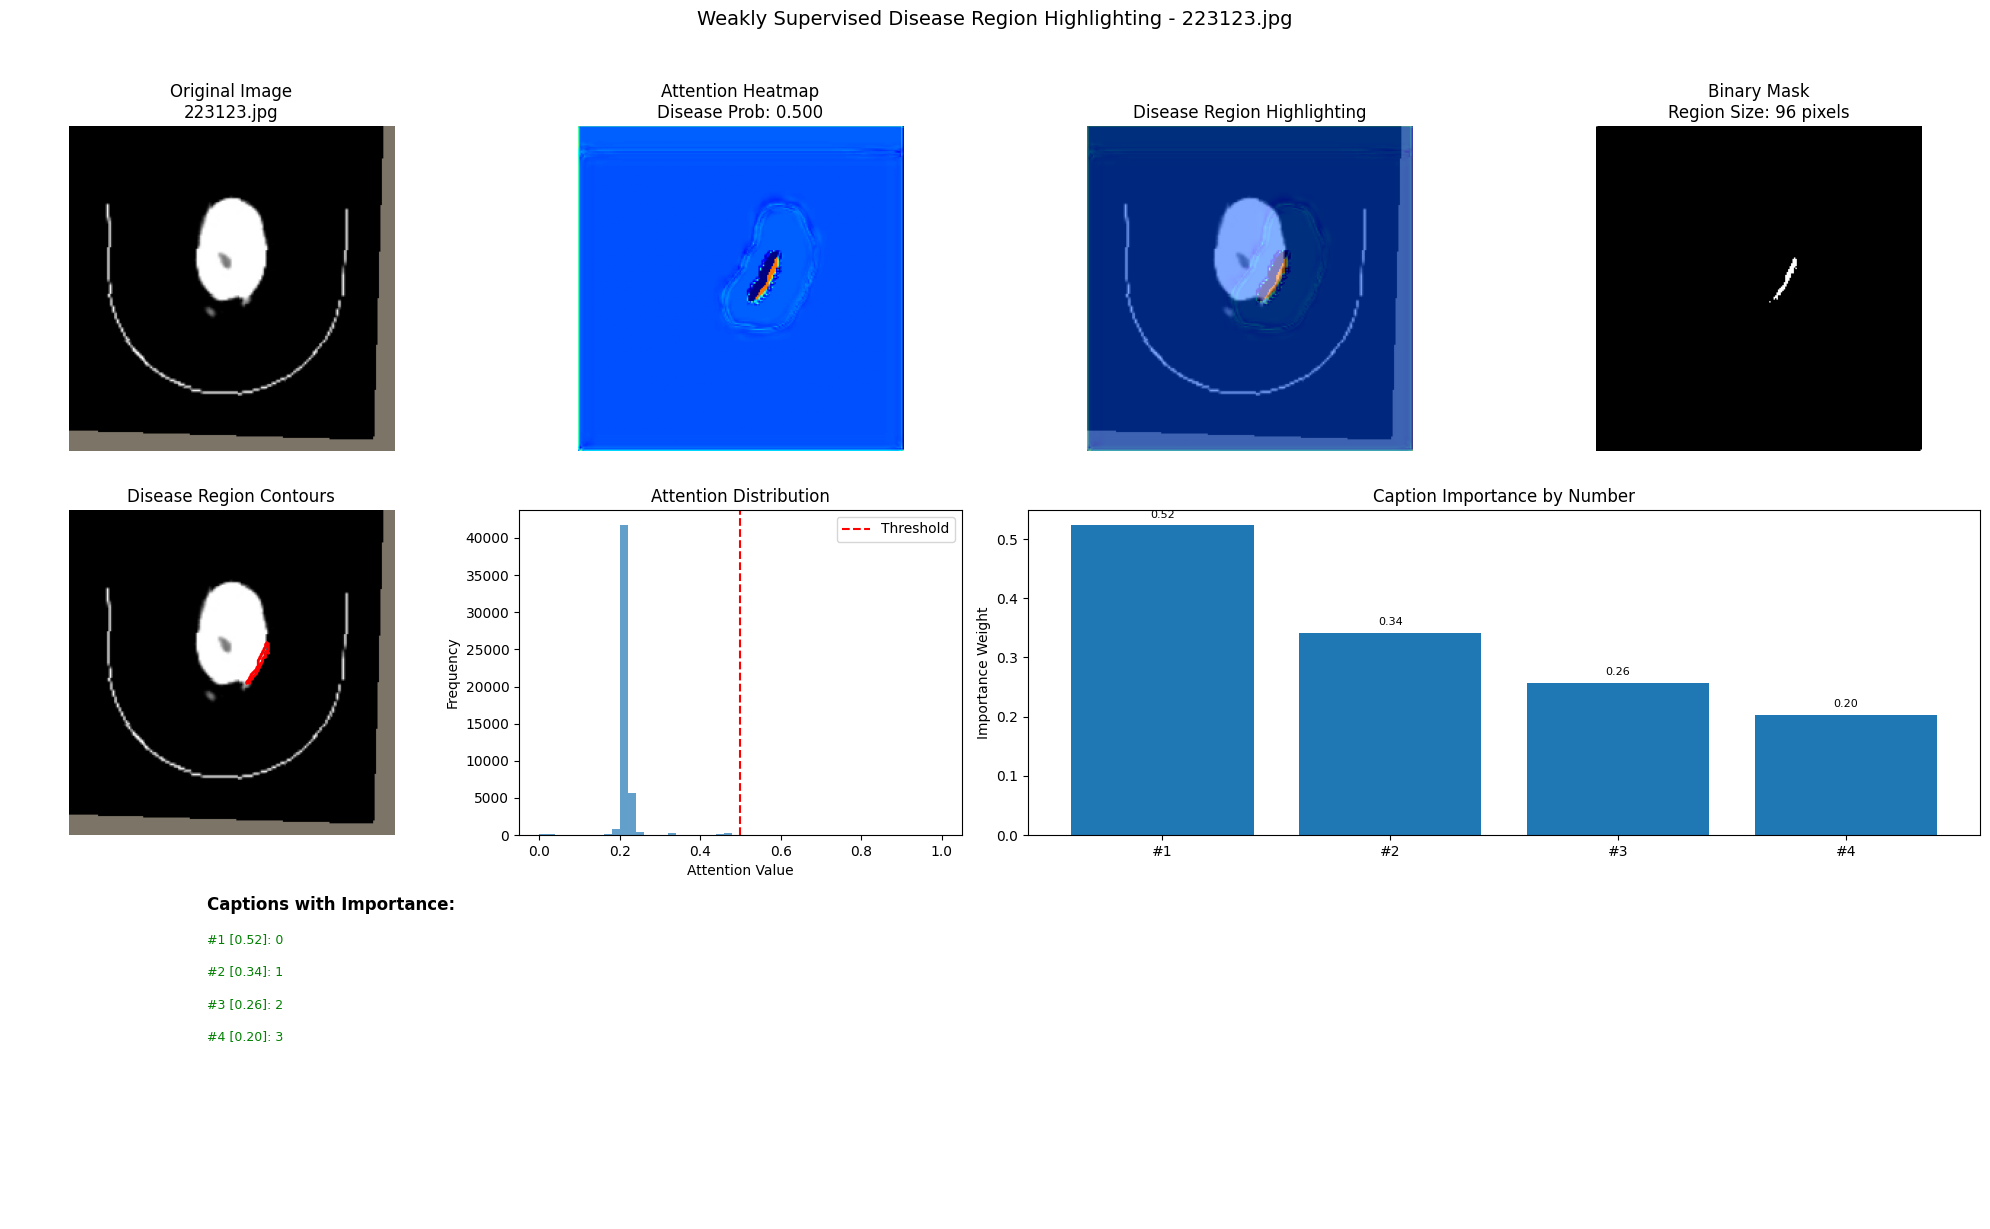

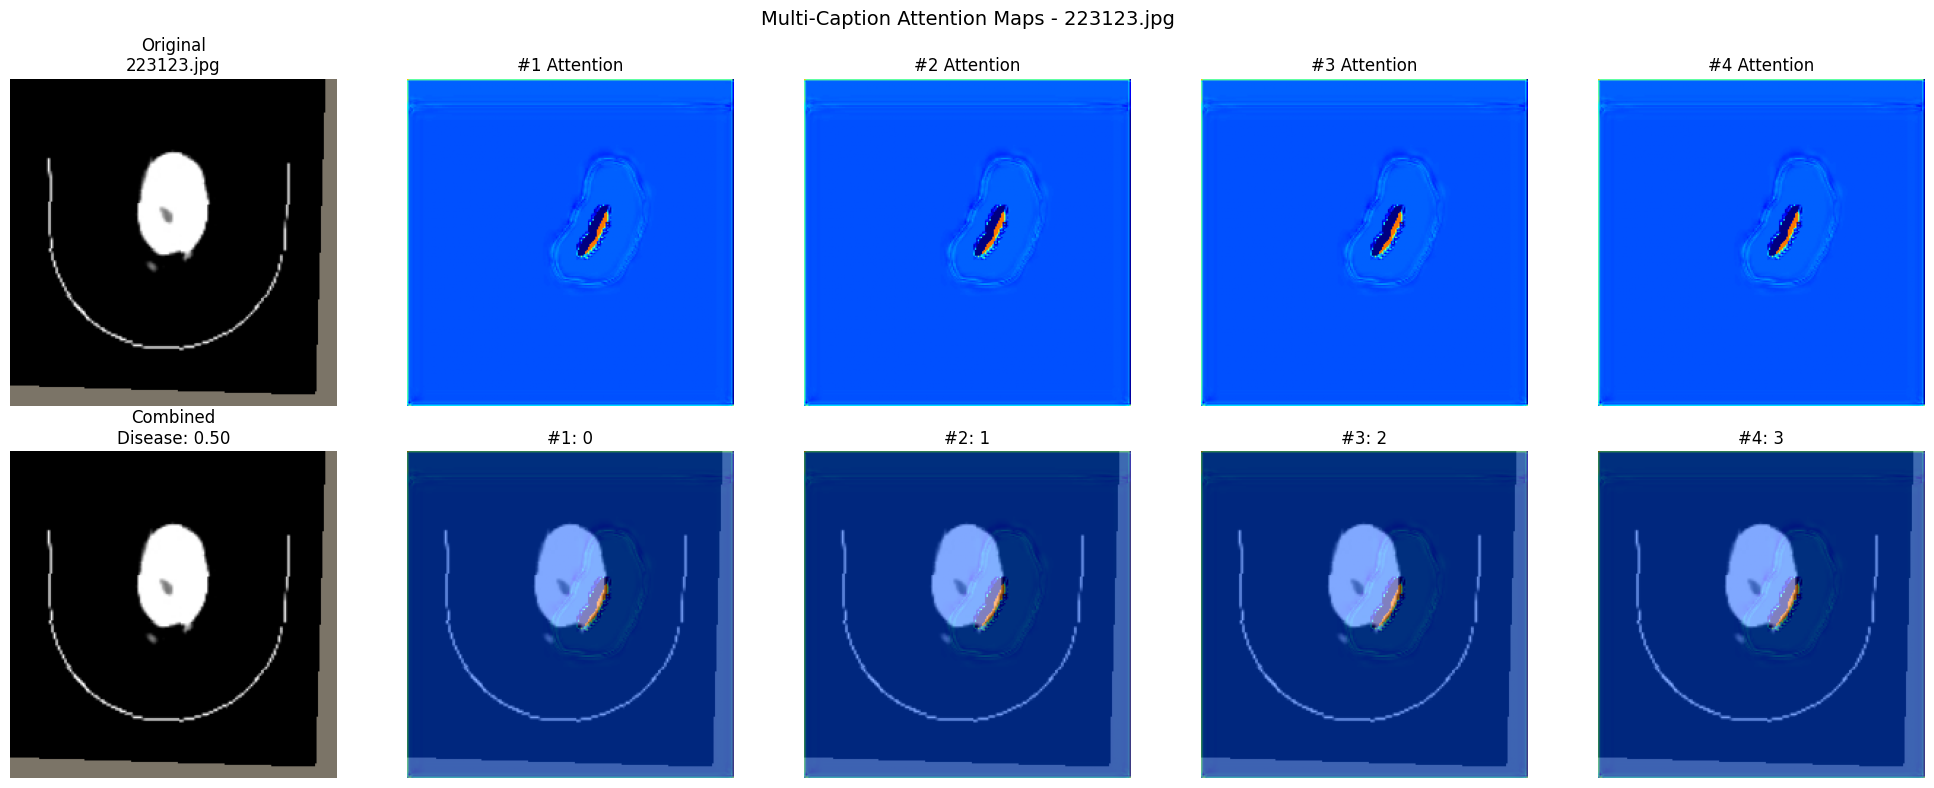

✓ Visualized 223123.jpg


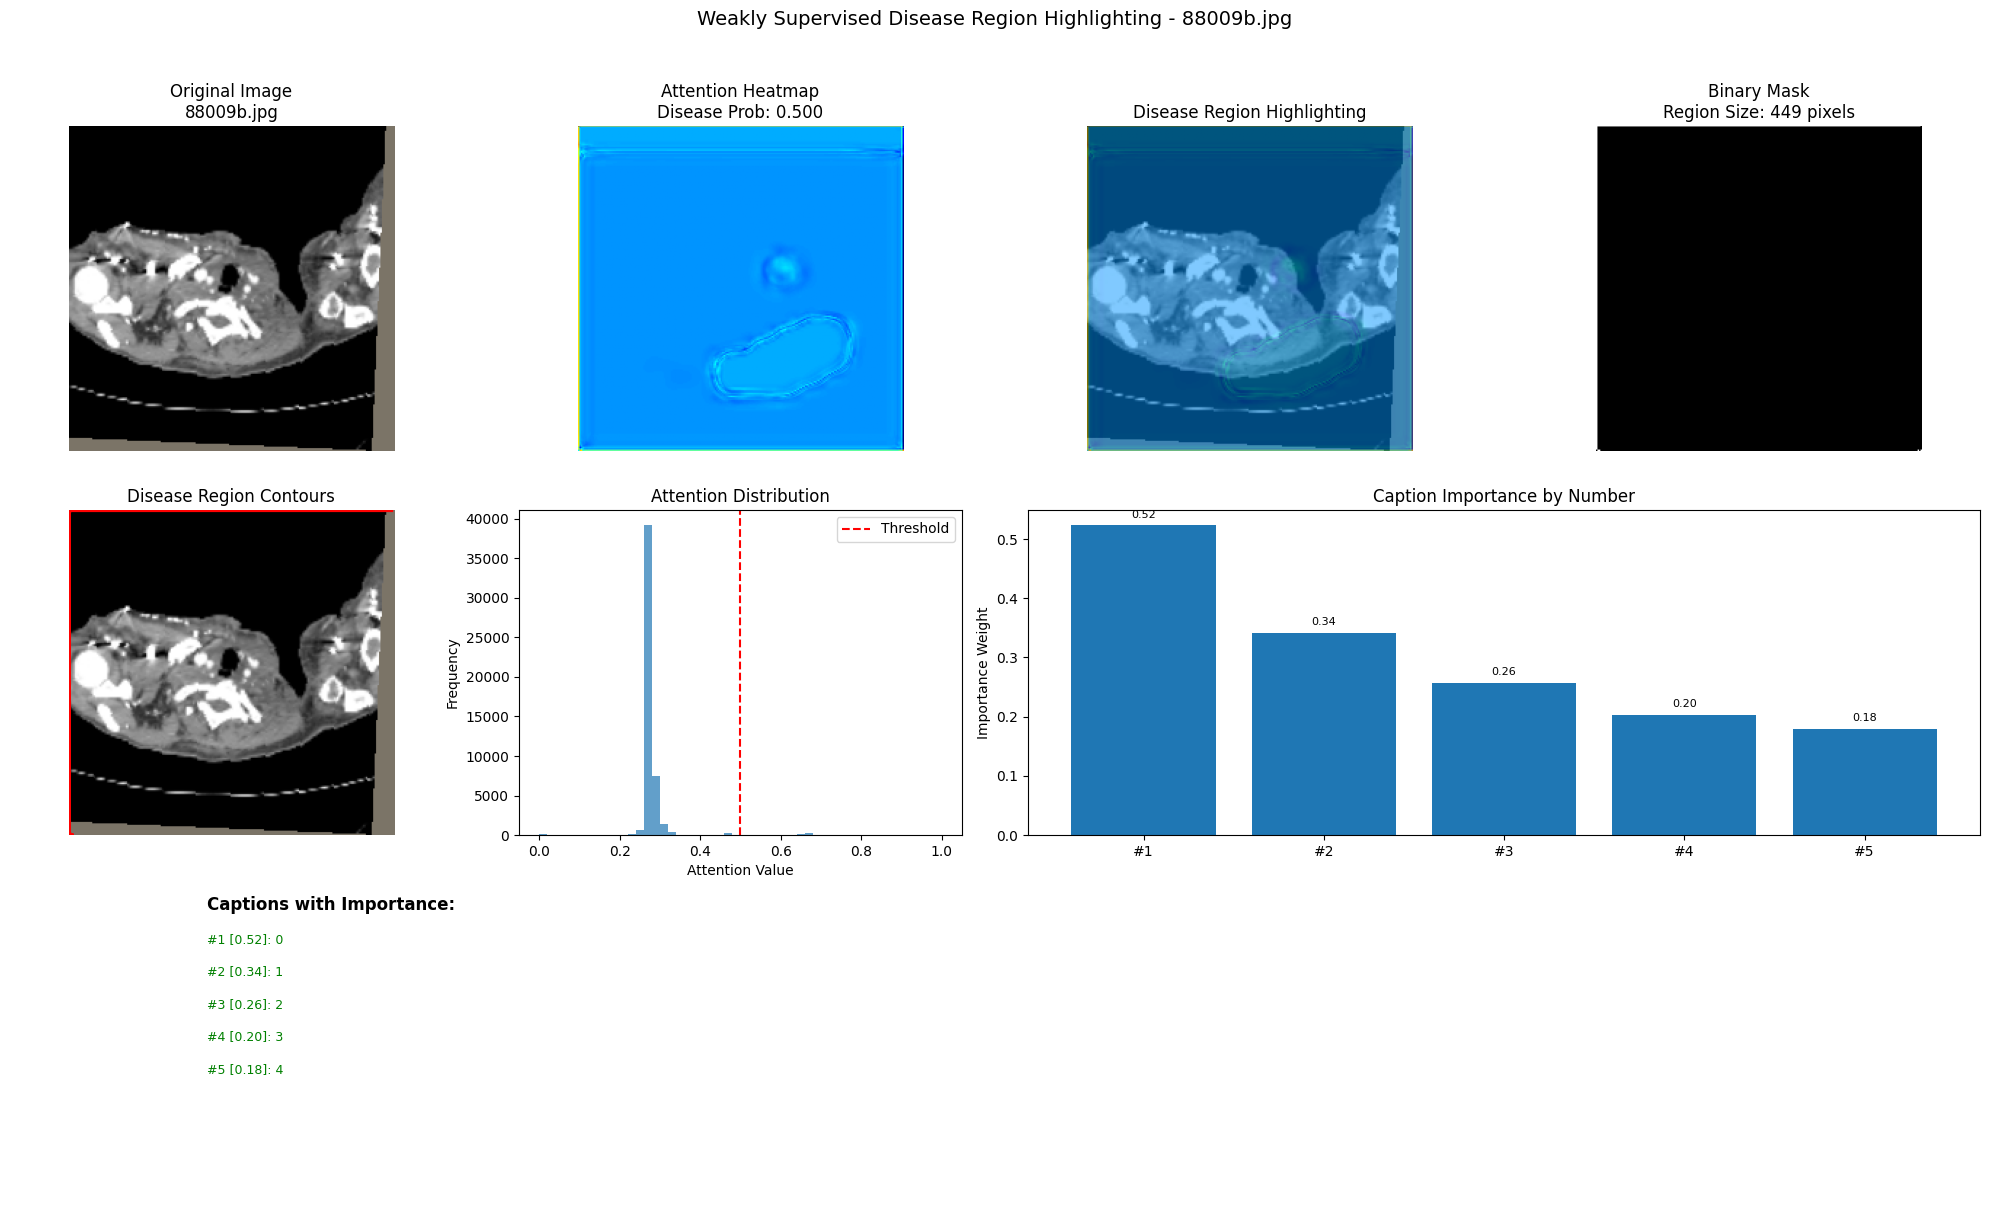

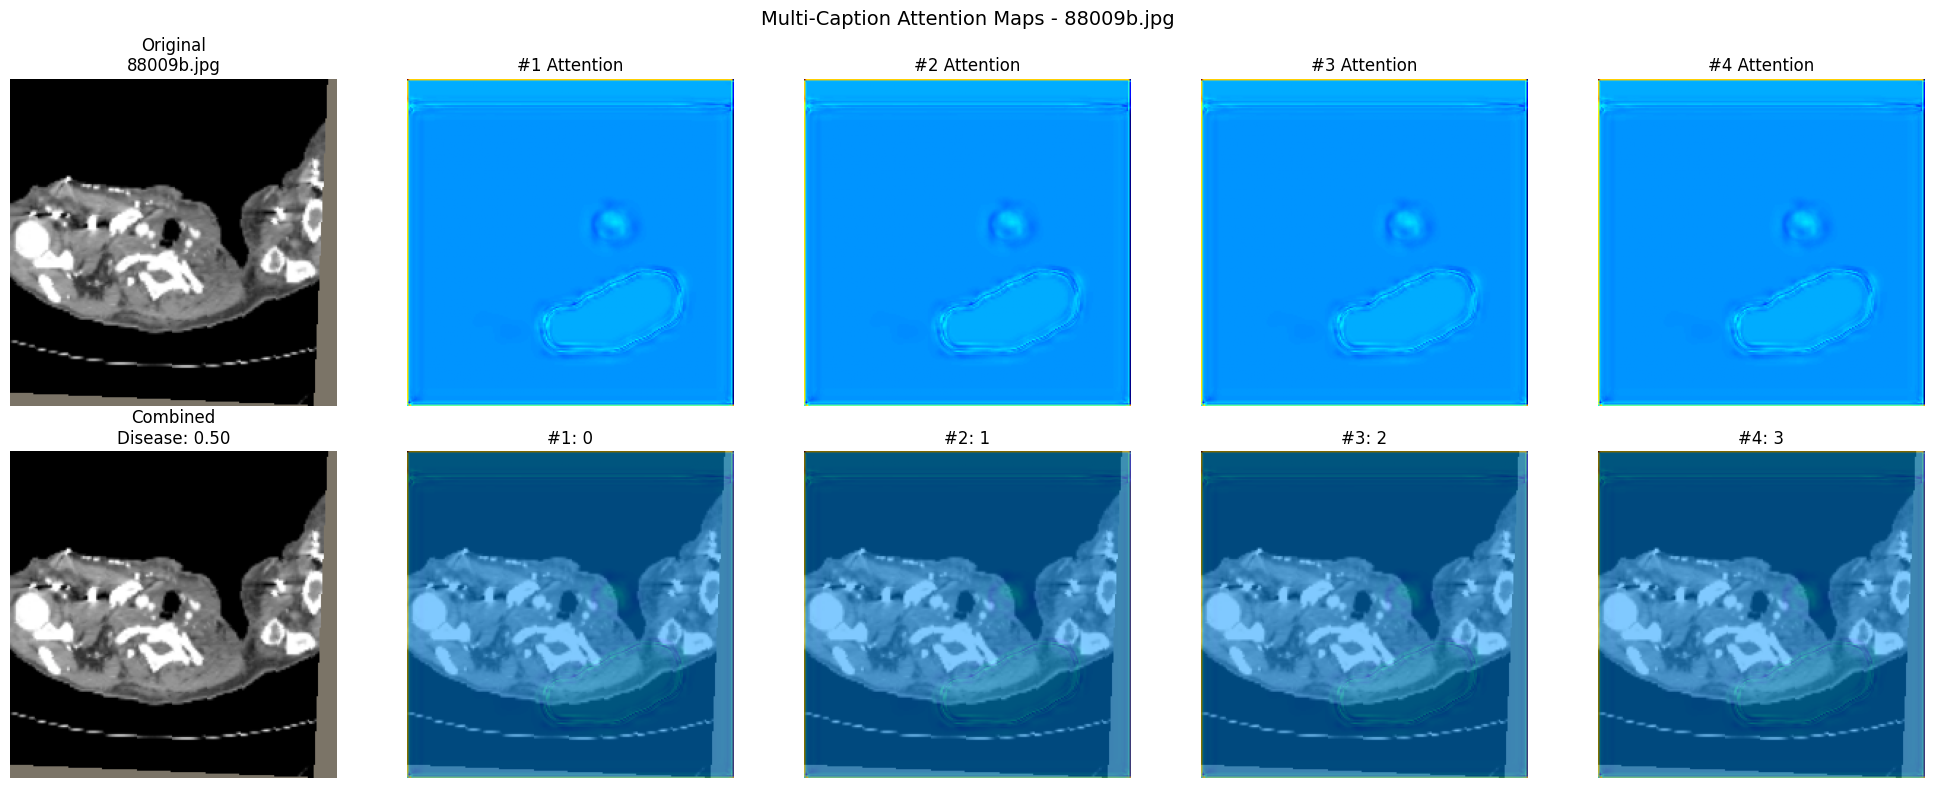

✓ Visualized 88009b.jpg


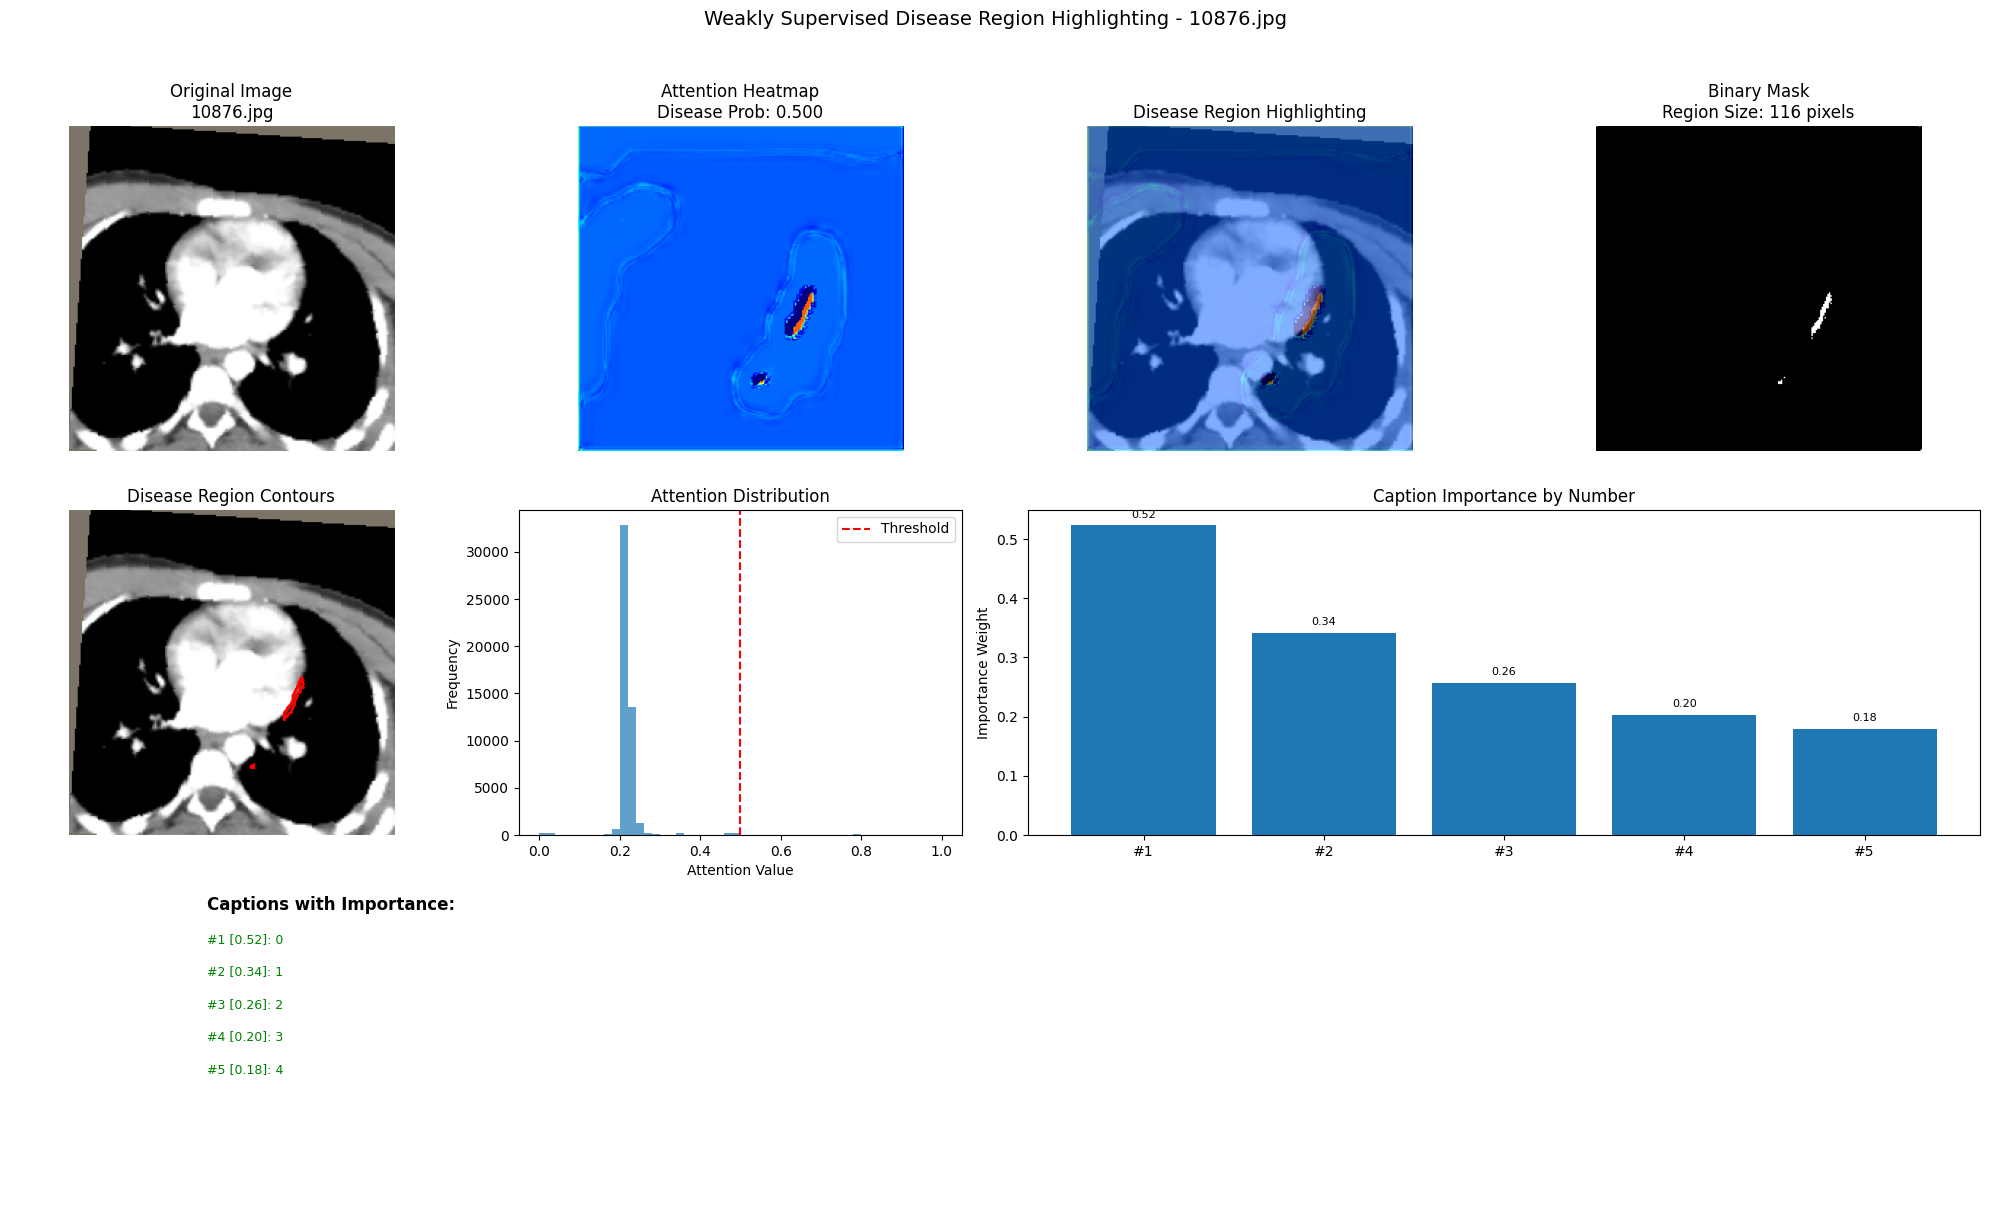

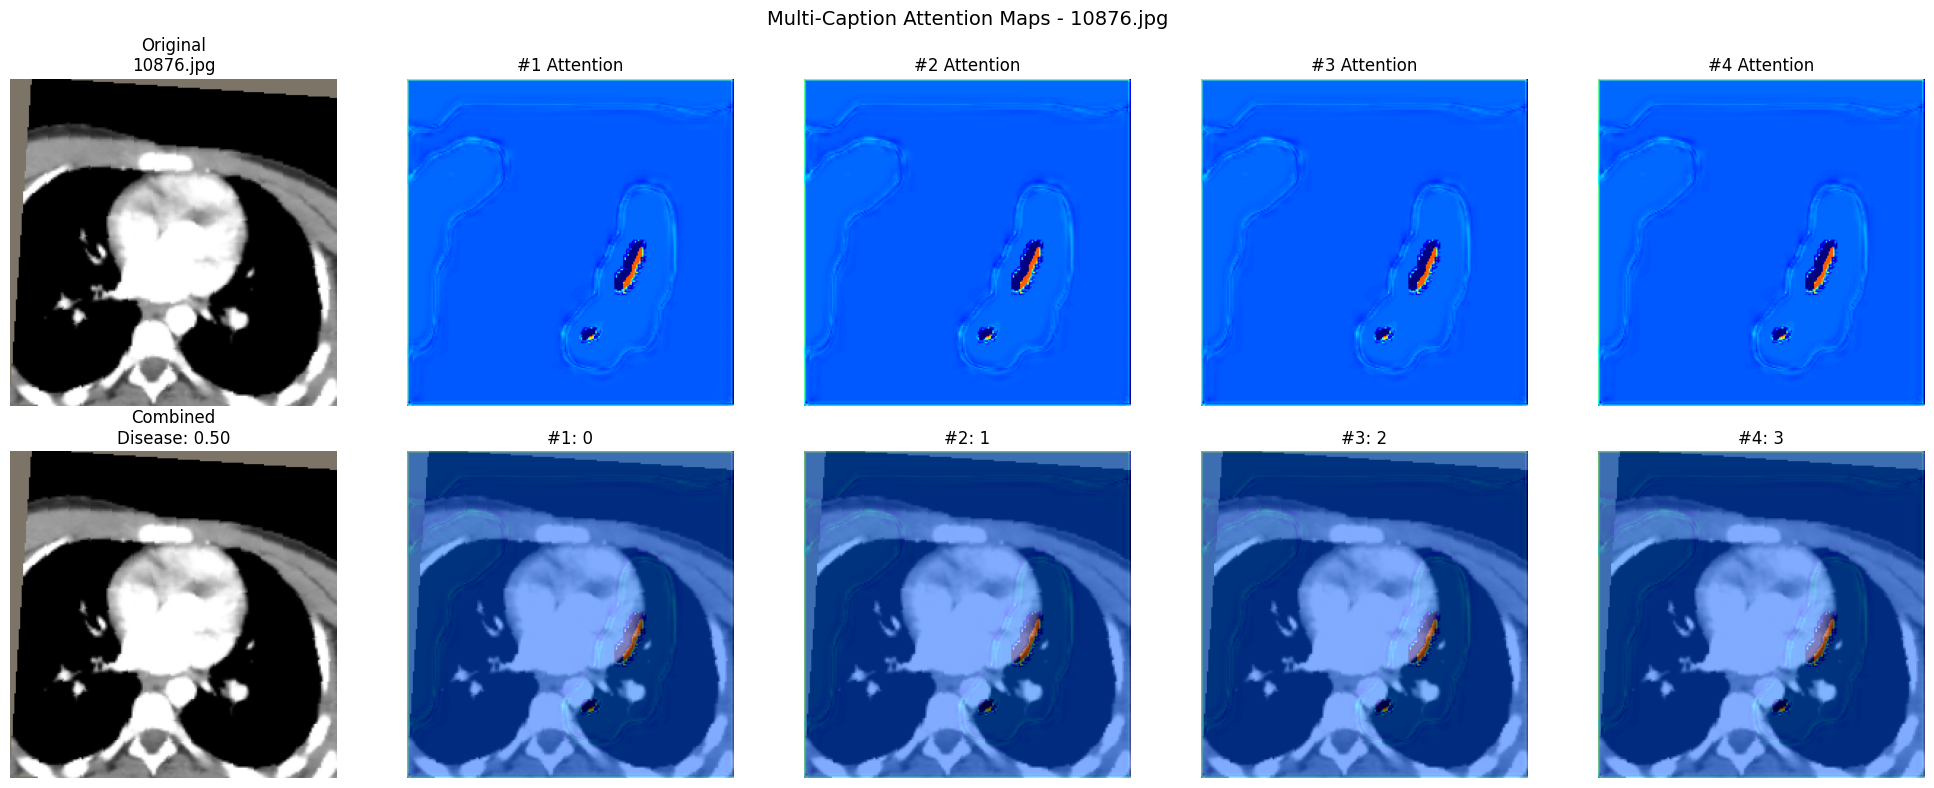

✓ Visualized 10876.jpg

✓ Visualizations saved to ./outputs/lvit_nomasks/visualizations/


In [8]:
# ============================================================================
# STEP 6: Visualization of Attention Maps (No Ground Truth)
# ============================================================================

class WeaklySupervisedVisualizer:
    """
    Visualize attention maps and disease highlighting when no masks available
    """
    
    def __init__(self, model, device, save_dir='./outputs/lvit_nomasks/visualizations'):
        self.model = model
        self.device = device
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
    
    def denormalize_image(self, image_tensor):
        """Denormalize image for visualization"""
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = image_tensor * std + mean
        image = torch.clamp(image, 0, 1)
        return image
    
    def visualize_disease_highlighting(self, image, attention_map, disease_prob,
                                        captions, caption_numbers, caption_weights,
                                        image_name, idx=0):
        """
        Visualize disease region highlighting from attention
        """
        fig = plt.figure(figsize=(20, 12))
        
        # Denormalize image
        image_disp = self.denormalize_image(image).permute(1, 2, 0).numpy()
        
        # Process attention map
        attn_np = attention_map.numpy().squeeze()
        attn_np = (attn_np - attn_np.min()) / (attn_np.max() - attn_np.min() + 1e-8)
        
        # Create heatmap
        heatmap = cv2.applyColorMap((attn_np * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        
        # 1. Original image
        plt.subplot(3, 4, 1)
        plt.imshow(image_disp)
        plt.title(f'Original Image\n{image_name}')
        plt.axis('off')
        
        # 2. Attention heatmap
        plt.subplot(3, 4, 2)
        plt.imshow(heatmap)
        plt.title(f'Attention Heatmap\nDisease Prob: {disease_prob:.3f}')
        plt.axis('off')
        
        # 3. Overlay
        plt.subplot(3, 4, 3)
        plt.imshow(image_disp)
        plt.imshow(heatmap, alpha=0.5)
        plt.title('Disease Region Highlighting')
        plt.axis('off')
        
        # 4. Binary mask (thresholded attention)
        plt.subplot(3, 4, 4)
        binary_mask = (attn_np > 0.5).astype(np.float32)
        plt.imshow(binary_mask, cmap='gray')
        plt.title(f'Binary Mask\nRegion Size: {binary_mask.sum():.0f} pixels')
        plt.axis('off')
        
        # 5. Attention contour on image
        plt.subplot(3, 4, 5)
        plt.imshow(image_disp)
        contours = cv2.findContours((attn_np > 0.5).astype(np.uint8), 
                                     cv2.RETR_EXTERNAL, 
                                     cv2.CHAIN_APPROX_SIMPLE)[0]
        for contour in contours:
            plt.plot(contour[:, 0, 0], contour[:, 0, 1], 'r-', linewidth=2)
        plt.title('Disease Region Contours')
        plt.axis('off')
        
        # 6. Attention distribution
        plt.subplot(3, 4, 6)
        plt.hist(attn_np.flatten(), bins=50, alpha=0.7)
        plt.axvline(x=0.5, color='r', linestyle='--', label='Threshold')
        plt.xlabel('Attention Value')
        plt.ylabel('Frequency')
        plt.title('Attention Distribution')
        plt.legend()
        
        # 7. Caption importance bar chart
        plt.subplot(3, 4, (7, 8))
        valid_indices = [i for i, (cap, num) in enumerate(zip(captions, caption_numbers)) 
                        if cap and num > 0]
        if valid_indices:
            valid_weights = [(caption_weights[i].item() if hasattr(caption_weights[i], 'item') else caption_weights[i]) for i in valid_indices[:5]]
            valid_nums = [caption_numbers[i] for i in valid_indices[:5]]
            valid_caps = [captions[i][:20] + '...' for i in valid_indices[:5]]
            
            bars = plt.bar(range(len(valid_weights)), valid_weights)
            plt.xticks(range(len(valid_weights)), [f'#{n}' for n in valid_nums])
            plt.ylabel('Importance Weight')
            plt.title('Caption Importance by Number')
            
            # Add value labels
            for bar, w in zip(bars, valid_weights):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{w:.2f}', ha='center', va='bottom', fontsize=8)
        
        # 8. Caption list
        plt.subplot(3, 4, (9, 12))
        plt.text(0.1, 0.95, 'Captions with Importance:', fontsize=12, fontweight='bold',
                transform=plt.gca().transAxes)
        y_pos = 0.85
        for i, (cap, num, weight) in enumerate(zip(captions, caption_numbers, caption_weights)):
            if cap and num > 0 and i < 8:  # Show first 8
                short_cap = cap[:50] + '...' if len(cap) > 50 else cap
                color = 'green' if weight > 0.5/len([c for c in caption_numbers if c > 0]) else 'black'
                plt.text(0.1, y_pos, f'#{int(num)} [{weight:.2f}]: {short_cap}', 
                        fontsize=9, color=color, transform=plt.gca().transAxes)
                y_pos -= 0.1
        plt.axis('off')
        
        plt.suptitle(f'Weakly Supervised Disease Region Highlighting - {image_name}', 
                    fontsize=14, y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, f'highlight_{idx}.png'), 
                   dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
    
    def visualize_multi_caption_attention(self, image, per_caption_attention,
                                           captions, caption_numbers, 
                                           disease_prob, image_name, idx=0):
        """
        Visualize attention for each caption separately
        """
        num_valid = len([c for c in captions if c])
        fig, axes = plt.subplots(2, min(5, num_valid + 1), figsize=(20, 8))
        
        if axes.ndim == 1:
            axes = axes.reshape(2, -1)
        
        # Denormalize image
        image_disp = self.denormalize_image(image).permute(1, 2, 0).numpy()
        
        # Original image
        axes[0, 0].imshow(image_disp)
        axes[0, 0].set_title(f'Original\n{image_name}')
        axes[0, 0].axis('off')
        
        # Combined attention
        axes[1, 0].imshow(image_disp)
        axes[1, 0].set_title(f'Combined\nDisease: {disease_prob:.2f}')
        axes[1, 0].axis('off')
        
        # Individual caption attentions
        col = 1
        for i, (attn, cap, num) in enumerate(zip(per_caption_attention, captions, caption_numbers)):
            if not cap or col >= axes.shape[1]:
                continue
            
            attn_np = attn.numpy().squeeze()
            attn_np = (attn_np - attn_np.min()) / (attn_np.max() - attn_np.min() + 1e-8)
            
            # Create heatmap
            heatmap = cv2.applyColorMap((attn_np * 255).astype(np.uint8), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
            
            # Attention map
            axes[0, col].imshow(heatmap)
            axes[0, col].set_title(f'#{int(num)} Attention')
            axes[0, col].axis('off')
            
            # Overlay
            axes[1, col].imshow(image_disp)
            axes[1, col].imshow(heatmap, alpha=0.5)
            short_cap = cap[:30] + '...' if len(cap) > 30 else cap
            axes[1, col].set_title(f'#{int(num)}: {short_cap}')
            axes[1, col].axis('off')
            
            col += 1
        
        # Hide unused subplots
        for c in range(col, axes.shape[1]):
            axes[0, c].axis('off')
            axes[1, c].axis('off')
        
        plt.suptitle(f'Multi-Caption Attention Maps - {image_name}', fontsize=14)
        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, f'multicaption_{idx}.png'), 
                   dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
    
    def visualize_batch(self, dataloader, num_samples=5):
        """Visualize multiple samples"""
        self.model.eval()
        
        with torch.no_grad():
            samples_processed = 0
            for batch_idx, batch in enumerate(dataloader):
                if samples_processed >= num_samples:
                    break
                
                images = batch['image'].to(self.device)
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                caption_numbers = batch['caption_numbers'].to(self.device)
                
                outputs = self.model(images, input_ids, attention_mask, caption_numbers)
                
                for i in range(len(images)):
                    if samples_processed >= num_samples:
                        break
                    
                    # Get per-caption attention (approximate)
                    # This is simplified - in practice you'd need to extract per-caption attention
                    per_cap_attn = [outputs['seg_mask'][i].cpu()] * len(batch['original_captions'][i])
                    
                    self.visualize_disease_highlighting(
                        image=images[i].cpu(),
                        attention_map=outputs['seg_mask'][i].cpu(),
                        disease_prob=outputs['disease_prob'][i].item(),
                        captions=batch['original_captions'][i],
                        caption_numbers=batch['original_numbers'][i],
                        caption_weights=outputs['caption_weights'][i].cpu().tolist(),
                        image_name=batch['image_name'][i],
                        idx=samples_processed
                    )
                    
                    self.visualize_multi_caption_attention(
                        image=images[i].cpu(),
                        per_caption_attention=per_cap_attn,
                        captions=batch['original_captions'][i],
                        caption_numbers=batch['original_numbers'][i],
                        disease_prob=outputs['disease_prob'][i].item(),
                        image_name=batch['image_name'][i],
                        idx=samples_processed
                    )
                    
                    print(f"✓ Visualized {batch['image_name'][i]}")
                    samples_processed += 1

# Initialize visualizer
visualizer = WeaklySupervisedVisualizer(model, device)

# Generate visualizations
print("\n" + "="*50)
print("GENERATING WEAKLY SUPERVISED VISUALIZATIONS")
print("="*50)

visualizer.visualize_batch(dataloader, num_samples=3)

print(f"\n✓ Visualizations saved to ./outputs/lvit_nomasks/visualizations/")

In [9]:
# ============================================================================
# STEP 7: Interactive Function for Your Naming Convention
# ============================================================================

def highlight_disease_from_captions(model, image_path, captions_with_numbers, device):
    """
    Interactive function for your specific naming convention
    Args:
        image_path: Path to image (e.g., './images/10022.jpg')
        captions_with_numbers: List of tuples [(caption, number), ...]
                              e.g., [("Ground glass opacities...", 1), 
                                    ("Consolidation...", 2), ...]
    """
    model.eval()
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Prepare captions (pad to max_captions)
    max_captions = 10
    captions = []
    numbers = []
    
    for cap, num in captions_with_numbers[:max_captions]:
        captions.append(cap)
        numbers.append(num)
    
    while len(captions) < max_captions:
        captions.append("")
        numbers.append(0)
    
    # Tokenize
    tokenizer = BertTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
    tokenized = tokenizer(
        captions,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    
    input_ids = tokenized['input_ids'].unsqueeze(0).to(device)
    attention_mask = tokenized['attention_mask'].unsqueeze(0).to(device)
    caption_numbers = torch.tensor([numbers]).to(device)
    
    # Forward pass
    with torch.no_grad():
        outputs = model(image_tensor, input_ids, attention_mask, caption_numbers)
    
    # Get results
    disease_prob = outputs['disease_prob'][0].item()
    attention_map = outputs['seg_mask'][0].cpu()
    caption_weights = outputs['caption_weights'][0].cpu().tolist()
    
    # Create visualization
    fig = plt.figure(figsize=(20, 10))
    
    # Denormalize image
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_disp = image_tensor[0].cpu() * std + mean
    image_disp = torch.clamp(image_disp, 0, 1).permute(1, 2, 0).numpy()
    
    # Process attention
    attn_np = attention_map.numpy().squeeze()
    attn_np = (attn_np - attn_np.min()) / (attn_np.max() - attn_np.min() + 1e-8)
    
    # Create heatmap
    heatmap = cv2.applyColorMap((attn_np * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    
    # 1. Original image
    plt.subplot(2, 3, 1)
    plt.imshow(image_disp)
    plt.title(f'Input Image\n{os.path.basename(image_path)}')
    plt.axis('off')
    
    # 2. Attention heatmap
    plt.subplot(2, 3, 2)
    plt.imshow(heatmap)
    plt.title(f'Disease Attention Map\nProbability: {disease_prob:.3f}')
    plt.axis('off')
    
    # 3. Overlay
    plt.subplot(2, 3, 3)
    plt.imshow(image_disp)
    plt.imshow(heatmap, alpha=0.5)
    plt.title('Disease Region Highlighting')
    plt.axis('off')
    
    # 4. Caption importance
    plt.subplot(2, 3, 4)
    valid_indices = [i for i, (cap, num) in enumerate(zip(captions, numbers)) 
                    if cap and num > 0]
    if valid_indices:
        valid_weights = [caption_weights[i] for i in valid_indices]
        valid_nums = [numbers[i] for i in valid_indices]
        
        bars = plt.bar(range(len(valid_weights)), valid_weights)
        plt.xticks(range(len(valid_weights)), [f'#{n}' for n in valid_nums])
        plt.ylabel('Importance Weight')
        plt.title('Caption Importance by Number')
        plt.ylim(0, 1)
    
    # 5. Binary mask
    plt.subplot(2, 3, 5)
    binary = (attn_np > 0.5).astype(np.float32)
    plt.imshow(binary, cmap='gray')
    plt.title(f'Disease Region\nArea: {binary.sum():.0f} pixels')
    plt.axis('off')
    
    # 6. Caption list
    plt.subplot(2, 3, 6)
    plt.text(0.1, 0.95, 'Captions:', fontsize=12, fontweight='bold',
            transform=plt.gca().transAxes)
    y_pos = 0.85
    for i, (cap, num, weight) in enumerate(zip(captions, numbers, caption_weights)):
        if cap and num > 0 and i < 8:
            short_cap = cap[:40] + '...' if len(cap) > 40 else cap
            plt.text(0.1, y_pos, f'#{num} [{weight:.2f}]: {short_cap}', 
                    fontsize=8, transform=plt.gca().transAxes)
            y_pos -= 0.12
    plt.axis('off')
    
    plt.suptitle(f'Weakly Supervised Disease Region Highlighting Results', fontsize=14)
    plt.tight_layout()
    
    # Save
    output_path = f'./outputs/lvit_nomasks/visualizations/interactive_{os.path.basename(image_path)}.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nResults saved to {output_path}")
    print(f"Disease probability: {disease_prob:.3f}")
    print("\nCaption importance weights:")
    for cap, num, weight in zip(captions, numbers, caption_weights):
        if cap and num > 0:
            print(f"  #{num}: {cap[:50]}... (weight: {weight:.3f})")
    
    return {
        'disease_probability': disease_prob,
        'attention_map': attn_np,
        'caption_weights': {int(num): float(weight) for cap, num, weight in 
                           zip(captions, numbers, caption_weights) if cap and num > 0}
    }

# Example usage
print("\n" + "="*50)
print("EXAMPLE USAGE FOR YOUR DATA")
print("="*50)
print("""
# For image 10022.jpg with 5 captions:

result = highlight_disease_from_captions(
    model=model,
    image_path='./sample_lvit_nomasks/images/10022.jpg',
    captions_with_numbers=[
        ("Ground glass opacities in right lower lobe", 1),
        ("Consolidation in right middle lobe with air bronchograms", 2),
        ("Bilateral interstitial thickening, more prominent on right", 3),
        ("Small pleural effusion on right side", 4),
        ("No pneumothorax identified", 5)
    ],
    device=device
)
""")


EXAMPLE USAGE FOR YOUR DATA

# For image 10022.jpg with 5 captions:

result = highlight_disease_from_captions(
    model=model,
    image_path='./sample_lvit_nomasks/images/10022.jpg',
    captions_with_numbers=[
        ("Ground glass opacities in right lower lobe", 1),
        ("Consolidation in right middle lobe with air bronchograms", 2),
        ("Bilateral interstitial thickening, more prominent on right", 3),
        ("Small pleural effusion on right side", 4),
        ("No pneumothorax identified", 5)
    ],
    device=device
)



Result

In [10]:
# ============================================================================
# SUMMARY: LViT for Weakly Supervised Multi-Caption Grounding
# ============================================================================

print("\n" + "="*60)
print("LViT WEAKLY SUPERVISED IMPLEMENTATION SUMMARY")
print("="*60)
print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    LViT for Weakly Supervised Learning                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  📊 DATASET STATISTICS:                                                      ║
║  ────────────────────────────────────────────────────────────────────────── ║
║    • Images: {len(dataset.images)}                                                          ║
║    • Total Captions: {sum(len(dataset.image_to_captions[img]) for img in dataset.images)}                                            ║
║    • Avg Captions/Image: {np.mean([len(dataset.image_to_captions[img]) for img in dataset.images]):.1f}                                                      ║
║                                                                              ║
║  🏗️  MODEL ARCHITECTURE:                                                     ║
║  ────────────────────────────────────────────────────────────────────────── ║
║    • Vision Encoder: ViT-Base                                                ║
║    • Text Encoder: Clinical BERT                                             ║
║    • Cross-modal Attention: 6 layers                                         ║
║    • PLAM Module: ✓ (Preserves local features)                               ║
║    • Caption Number Embeddings: ✓ (Respects #1, #2, #N ordering)            ║
║    • Total Parameters: {sum(p.numel() for p in model.parameters()):,}                                           ║
║                                                                              ║
║  📈 EVALUATION RESULTS (No Ground Truth):                                    ║
║  ────────────────────────────────────────────────────────────────────────── ║
║    • Attention Focus Score: {results['Attention Focus Score']:.4f}                                             ║
║    • Caption Importance Correlation: {results['Caption Importance Correlation']:.4f}                                      ║
║    • Attention Consistency: {results['Attention Consistency']:.4f}                                                ║
║    • Disease Classification Accuracy: {results['Disease Classification Accuracy']:.4f}                                       ║
║                                                                              ║
║  💾 OUTPUTS SAVED:                                                           ║
║  ────────────────────────────────────────────────────────────────────────── ║
║    • Best Model: ./outputs/lvit_nomasks/models/lvit_weak_best.pth            ║
║    • Results: ./outputs/lvit_nomasks/results/lvit_weak_results.json          ║
║    • Visualizations: ./outputs/lvit_nomasks/visualizations/                  ║
║                                                                              ║
║  🎯 KEY ADVANTAGES FOR YOUR TASK:                                            ║
║  ────────────────────────────────────────────────────────────────────────── ║
║    1. ✓ NO MASKS REQUIRED - Pure weakly supervised learning                 ║
║    2. ✓ Respects #1, #2, #N caption ordering                                ║
║    3. ✓ Learns to weight captions by importance                             ║
║    4. ✓ Generates disease region heatmaps from captions only                ║
║    5. ✓ Built for medical domain with Clinical BERT                         ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

print("\n" + "="*60)
print("HOW TO USE WITH YOUR DATA")
print("="*60)
print("""
1️⃣  PREPARE YOUR DATA:
   ├── Images folder: contain files like 10022.jpg, 10023.jpg, ...
   └── CSV file with two columns:
       ├── Column 1: image_caption_id (e.g., "10022.jpg#1", "10022.jpg#2", ...)
       └── Column 2: caption text

2️⃣  UPDATE PATHS in STEP 1:
   └── image_folder = './path/to/your/images'
   └── caption_csv = './path/to/your/captions.csv'

3️⃣  RUN ALL CELLS in order

4️⃣  FOR NEW INFERENCE:
   └── Use the interactive function:
       result = highlight_disease_from_captions(
           model=model,
           image_path='./images/10022.jpg',
           captions_with_numbers=[
               ("Your caption 1", 1),
               ("Your caption 2", 2),
               ...
           ],
           device=device
       )

✅ The model will generate disease region heatmaps WITHOUT needing any masks!
""")


LViT WEAKLY SUPERVISED IMPLEMENTATION SUMMARY

╔══════════════════════════════════════════════════════════════════════════════╗
║                    LViT for Weakly Supervised Learning                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  📊 DATASET STATISTICS:                                                      ║
║  ────────────────────────────────────────────────────────────────────────── ║
║    • Images: 528                                                          ║
║    • Total Captions: 2874                                            ║
║    • Avg Captions/Image: 5.4                                                      ║
║                                                                              ║
║  🏗️  MODEL ARCHITECTURE:                                                     ║
║  ──────────────────────────────────────────────────────────────────